Analyze time-series data from platereader experiments.

## Setup

In [ ]:
try:
    import cdk
    print("CDK already installed, skipping installation and restart.")
except ImportError:
    !pip install nucleus-cdk -q > /dev/null 2>&1
    print("\nInstallation complete. Restarting runtime to refresh dependencies...")
    import os
    os._exit(0)

CDK already installed, skipping installation and restart.


In [ ]:

import pandas as pd
pd.set_option('display.max_columns', None)
import seaborn as sns
import matplotlib.pyplot as plt

# Import the cdk platereader module
from cdk.instruments import platereader as pr

from cdk import logging
log = logging.setup_logging(logging.ERROR)

## Load Data

In [ ]:
%%writefile drive_utils.py
import os
import re

import gdown


def get_drive_file_id(url):
    """Extract the file ID from a Google Drive share URL."""
    match = re.search(r'/d/([a-zA-Z0-9_-]+)', url)
    if match:
        return match.group(1)
    return None


def download_from_drive(files_info, destination_dir):
    """
    Download files from Google Drive.

    Args:
        files_info (list): List of dicts with 'url' and 'filename'.
        destination_dir (str): Local path to save files.
    Returns:
        dict: Mapping of filenames to local paths.
    """
    os.makedirs(destination_dir, exist_ok=True)

    paths = {}
    for item in files_info:
        url = item['url']
        filename = item['filename']
        dest = os.path.join(destination_dir, filename)
        file_id = get_drive_file_id(url)

        if file_id:
            gdown.download(id=file_id, output=dest, quiet=True)
        else:
            gdown.download(url, output=dest, quiet=True)

        paths[filename] = dest
    return paths

Writing drive_utils.py


In [ ]:
# Set use_drive = True to download data_file and platemap_file from Google Drive instead of
# using local files. Each Drive file must have its permissions set to "Anyone with a link" can "view".
use_drive = True

if use_drive:
    from drive_utils import download_from_drive

    files_to_download = [
        {
            "url": "https://drive.google.com/file/d/1oB_drvnZlumdGA3YeNzLriyyOfpD0Tf2/view?usp=share_link",  # Replace with your data file link.
            "filename": "raw_data.txt",
        },
        {
            "url": "https://drive.google.com/file/d/14mr1h7jZeJneQKCLnzcGVZnuyMuyPIkv/view?usp=share_link",  # Replace with your platemap file link.
            "filename": "platemap.csv",
        },
    ]
    downloaded_paths = download_from_drive(files_to_download, destination_dir="data")
    data_file = downloaded_paths["raw_data.txt"]
    platemap_file = downloaded_paths["platemap.csv"]
else:
    data_file = "sample-data/20251111-122213-cytation5-pure-timecourse-gfp-MFG-98-tRNA-QC.txt"
    platemap_file = "sample-data/platemap.csv"

print(f"Data file: {data_file}\nPlatemap file: {platemap_file}")

Data file: data/raw_data.txt
Platemap file: data/platemap.csv


In [ ]:
# Load data
result = pr.load_platereader_data(
    data_file=data_file,
    platemap_file=platemap_file,
    platereader="biotek" # options: "biotek"
)

The output is a list of `PlateReaderResult` objects; if you did more than one read on the plate reader, the results will be in separate objects.

In [ ]:
print(result)

PlateReaderResult with the following 3 blocks:
0: (2117, 40) kinetic read with reads: GFP-G50:485/20,528/20 (Fluorescence) (Plate 'Plate 1')
1: (2117, 40) kinetic read with reads: GFP-G35:485/20,528/20 (Fluorescence) (Plate 'Plate 1')
2: (348, 38) endpoint read with reads: Max V [GFP-G50:485/20,528/20] (Fluorescence), R-Squared [GFP-G50:485/20,528/20] (Fluorescence), t at Max V [GFP-G50:485/20,528/20] (Fluorescence), Lagtime [GFP-G50:485/20,528/20] (Fluorescence), Max V [GFP-G35:485/20,528/20] (Fluorescence), R-Squared [GFP-G35:485/20,528/20] (Fluorescence), t at Max V [GFP-G35:485/20,528/20] (Fluorescence), Lagtime [GFP-G35:485/20,528/20] (Fluorescence), Count (None), Mean (None), Std Dev (None), CV (%) (None) (Plate 'Plate 1')


Here there were two reads with different gains but the same excitation/emission spectrum, on one plate. If we want just the `GFP-Gext` read, this corresponds to block index 1, so we can extract that block by indexing:

In [ ]:
desired_index = 1
data = result[desired_index]

You can see the underlying data with `data.view()` (which returns a Pandas DataFrame):

In [ ]:
data.view().head()

,Date,Experiment,Well,Name,Type,Time,Data,Read,Read Name,Reader Type,Reader ID,Plate Type,Plate ID,Start Time,Read Modality,Gain,Excitation Wavelength (nm),Excitation Bandwidth (nm),Excitation Optics,Emission Wavelength (nm),Emission Bandwidth (nm),Emission Optics,Read Geometry,Read Height (mm),Rxn Volume (uL),EsaR Vol (uL),DNA Template (nM),[AHSL] (uM),[Fluorescein] (uM)
0,2026-09-24,[EsaO]2-mNG DNA template titration +/- AHSL (E...,B2,mNG,Sample,0 days 00:00:31,4,"GFP-G35:485/20,528/20",GFP-G35,Synergy 2,206621,Greiner 384 SV NoBind Automap,Plate 1,2026-09-26 11:54:05,Fluorescence,35,485,20,filter,528,20,filter,Top 510 nm,7 mm,10,0.0,0.0,0,NaN
1,2026-09-24,[EsaO]2-mNG DNA template titration +/- AHSL (E...,B2,mNG,Sample,0 days 00:05:31,3,"GFP-G35:485/20,528/20",GFP-G35,Synergy 2,206621,Greiner 384 SV NoBind Automap,Plate 1,2026-09-26 11:54:05,Fluorescence,35,485,20,filter,528,20,filter,Top 510 nm,7 mm,10,0.0,0.0,0,NaN
2,2026-09-24,[EsaO]2-mNG DNA template titration +/- AHSL (E...,B2,mNG,Sample,0 days 00:10:31,12,"GFP-G35:485/20,528/20",GFP-G35,Synergy 2,206621,Greiner 384 SV NoBind Automap,Plate 1,2026-09-26 11:54:05,Fluorescence,35,485,20,filter,528,20,filter,Top 510 nm,7 mm,10,0.0,0.0,0,NaN
3,2026-09-24,[EsaO]2-mNG DNA template titration +/- AHSL (E...,B2,mNG,Sample,0 days 00:15:31,162,"GFP-G35:485/20,528/20",GFP-G35,Synergy 2,206621,Greiner 384 SV NoBind Automap,Plate 1,2026-09-26 11:54:05,Fluorescence,35,485,20,filter,528,20,filter,Top 510 nm,7 mm,10,0.0,0.0,0,NaN
4,2026-09-24,[EsaO]2-mNG DNA template titration +/- AHSL (E...,B2,mNG,Sample,0 days 00:20:31,477,"GFP-G35:485/20,528/20",GFP-G35,Synergy 2,206621,Greiner 384 SV NoBind Automap,Plate 1,2026-09-26 11:54:05,Fluorescence,35,485,20,filter,528,20,filter,Top 510 nm,7 mm,10,0.0,0.0,0,NaN


## Plot Raw Curves

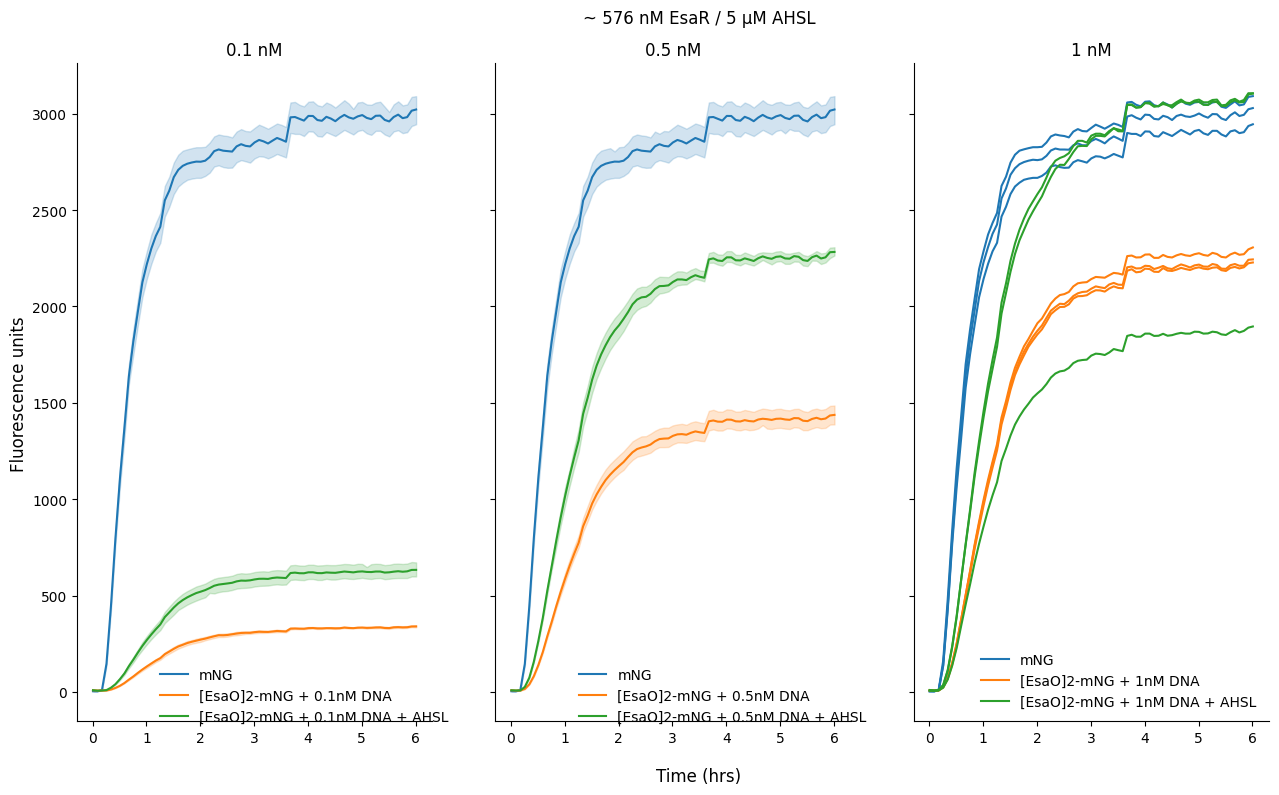

In [ ]:
#| label: cn-20250926-fig1

data_EsaO2_01 = data.select(name=["[EsaO]2-mNG + 0.1nM DNA", "[EsaO]2-mNG + 0.1nM DNA + AHSL","mNG" ])
data_EsaO2_05 = data.select(name=["[EsaO]2-mNG + 0.5nM DNA", "[EsaO]2-mNG + 0.5nM DNA + AHSL", "mNG"])
data_EsaO2_1 = data.select(name=["[EsaO]2-mNG + 1nM DNA", "[EsaO]2-mNG + 1nM DNA + AHSL", "mNG"])

df_1 = data_EsaO2_01.data
df_2 = data_EsaO2_05.data
df_3 = data_EsaO2_1.data


# convert timedelta -> float hours
for df in (df_1, df_2, df_3):
    df['Time_hrs'] = df['Time'].dt.total_seconds() / 3600

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13,8), sharey=True)
fig.suptitle('~ 576 nM EsaR / 5 µM AHSL', x=0.55)

sns.lineplot(data=df_1, x='Time_hrs', y='Data', hue='Name', ax=ax1)
sns.lineplot(data=df_2, x='Time_hrs', y='Data', hue='Name', ax=ax2)
sns.lineplot(data=df_3, x='Time_hrs', y='Data', hue='Name', ax=ax3, units='Well', estimator=None)

ax1.set(title='0.1 nM', ylabel='', xlabel='')
ax2.set(title='0.5 nM', ylabel='', xlabel='')
ax3.set(title='1 nM', ylabel='', xlabel='')

fig.supxlabel('Time (hrs)', x=0.55)
fig.supylabel('Fluorescence units')

for ax in (ax1, ax2, ax3):
    ax.legend(frameon=False)

ax1.legend(loc='upper center', bbox_to_anchor=(0.64, 0.1), frameon=False)
ax2.legend(loc='upper center', bbox_to_anchor=(0.64, 0.1), frameon=False)


sns.despine(fig)
fig.tight_layout()

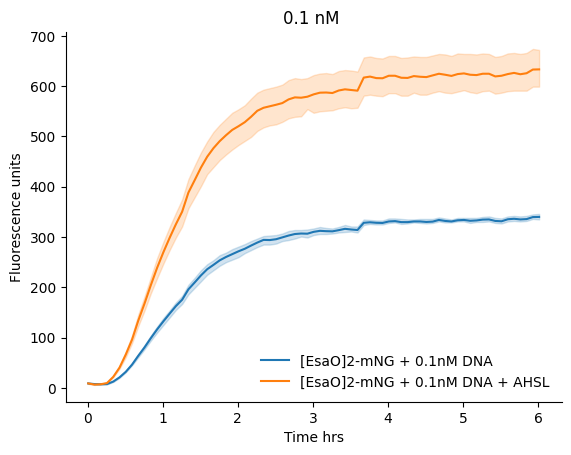

In [ ]:
sns.lineplot(data=df_1, x='Time_hrs', y='Data', hue='Name')

plt.title("0.1 nM ")
plt.xlabel("Time hrs")
plt.ylabel("Fluorescence units")
plt.legend(frameon=False)
sns.despine()




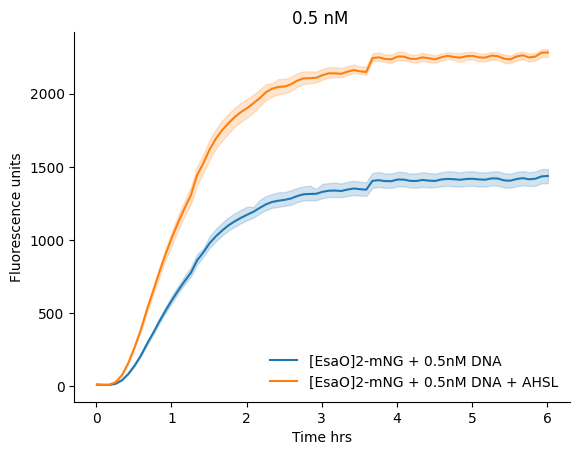

In [ ]:
sns.lineplot(data=df_2, x='Time_hrs', y='Data', hue='Name')

plt.title("0.5 nM ")
plt.xlabel("Time hrs")
plt.ylabel("Fluorescence units")
plt.legend(frameon=False)
sns.despine()


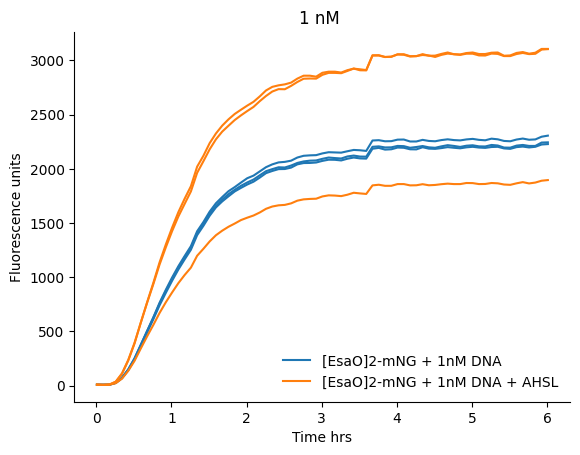

In [ ]:
sns.lineplot(data=df_3, x='Time_hrs', y='Data', hue='Name', units="Well", estimator = None)

plt.title("1 nM ")
plt.xlabel("Time hrs")
plt.ylabel("Fluorescence units")
plt.legend(frameon=False)
sns.despine()

In [ ]:
def steady_state_fold_change(df, base_name, ahsl_name, n_last=10):
    tail = df.groupby('Name').apply(lambda g: g.nlargest(n_last, 'Time_hrs')['Data'].mean())
    return tail[ahsl_name] / tail[base_name]

fc_01 = steady_state_fold_change(df_1, "[EsaO]2-mNG + 0.1nM DNA", "[EsaO]2-mNG + 0.1nM DNA + AHSL")
fc_05 = steady_state_fold_change(df_2, "[EsaO]2-mNG + 0.5nM DNA", "[EsaO]2-mNG + 0.5nM DNA + AHSL")
fc_1  = steady_state_fold_change(df_3, "[EsaO]2-mNG + 1nM DNA",   "[EsaO]2-mNG + 1nM DNA + AHSL")

# --- tidy into one summary table ---
fold_summary = pd.DataFrame({
    'DNA_conc_nM': [0.1, 0.5, 1],
    'Fold_change': [fc_01, fc_05, fc_1]
})
print(fold_summary)


   DNA_conc_nM  Fold_change
0          0.1     1.871863
1          0.5     1.589792
2          1.0     1.162061


/tmp/ipykernel_1683/2813574122.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tail = df.groupby('Name').apply(lambda g: g.nlargest(n_last, 'Time_hrs')['Data'].mean())
/tmp/ipykernel_1683/2813574122.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tail = df.groupby('Name').apply(lambda g: g.nlargest(n_last, 'Time_hrs')['Data'].mean())
/tmp/ipykernel_1683/2813574122.py:2: DeprecationWarning: DataFrame

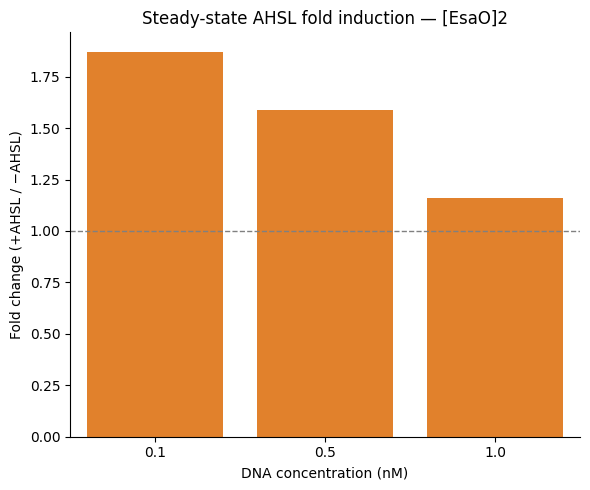

In [ ]:
fig, ax = plt.subplots(figsize=(6,5))

sns.barplot(data=fold_summary, x='DNA_conc_nM', y='Fold_change', ax=ax, color='tab:orange')

ax.set(xlabel='DNA concentration (nM)', ylabel='Fold change (+AHSL / −AHSL)')
ax.set_title('Steady-state AHSL fold induction — [EsaO]2')
ax.axhline(1, color='grey', linestyle='--', linewidth=1)

sns.despine(fig)
fig.tight_layout()
plt.show()

We can see that the standard (here, HPTS) is stable and can be safely used for normalization.

## Normalize Data
Now, use `data.normalize('<standard name>')` to normalize your data. This will calculate the average over a time window at the end of the experiment (by default, 1 hour), then divide all data by the mean of that window-average across all wells with the same `Name` (defined by your platemap).

In [ ]:
# To check the exact name of your standard
platemap = data.platemap
standards = platemap[platemap['Type']=='Standard']
standards['Name'].unique()

array(['10 uM HPTS'], dtype=object)

In [ ]:
data = data.normalize('10 uM HPTS')

Now replot your curves to see them normalized:

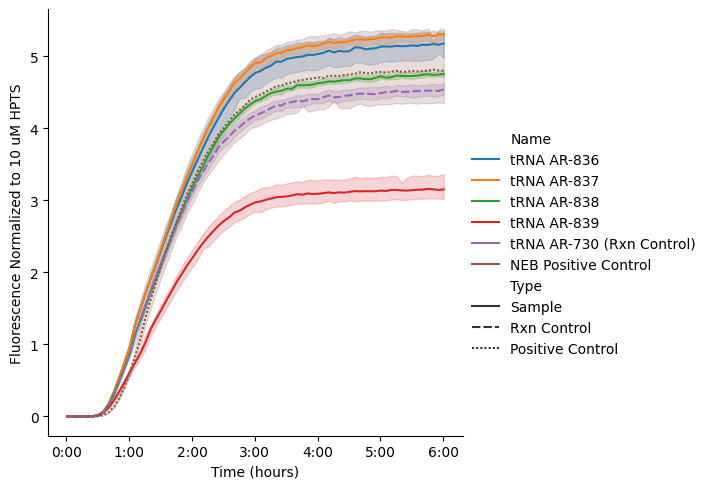

In [ ]:
g = data.plot(style='Type', exclude_types=['Standard'])
# g.savefig('after-normalization.png',dpi=300)

If you want to change the time window over which you calculate the average, you can use the `window` argument:

In [ ]:
# data = data.normalize('10 uM HPTS', window=pd.Timedelta("2.5h"))

## Kinetic Analysis

See the [DevNote](https://devnotes.nucleus.engineering/articles/Newman-20260421) on kinetic analysis for more details.

**Metrics extracted:**

  - **Maximum velocity**: Maximum rate of fluorescence increase (slope at inflection point)
  - **Lag time**: Time to reach the exponential phase
  - **Steady-state**: Final fluorescence level
  - **Time-to-completion**: Time it takes to reach 95% of asymptote
  - **Drift**: Rate of signal decay or increase after steady-state
  - **R²**: Goodness of fit; "Good Fit" is `True` if $R^2 \geq 0.95$

In [ ]:
# Perform kinetic analysis using sigmoid_drift model
kinetics = data.fit_kinetics()

[07/16/26 17:29:20] INFO     Calculating Kinetics                analysis.py:223


In [ ]:
kinetics.summary

,Well,Name,Max Velocity,Max Velocity Time,Lag Time,Steady State,Completion Time,Completion Threshold,Drift,Fit Function,R^2,Good Fit,Normalized to
0,B2,tRNA AR-836,2.49,0 days 01:33:15,0 days 00:33:09,4.74,0 days 03:01:44,0.95,0.07,sigmoid_drift,1.00,True,10 uM HPTS
1,B4,tRNA AR-837,2.67,0 days 01:33:35,0 days 00:34:38,4.99,0 days 03:00:24,0.95,0.07,sigmoid_drift,1.00,True,10 uM HPTS
2,B6,tRNA AR-838,2.44,0 days 01:32:35,0 days 00:34:21,4.50,0 days 02:58:17,0.95,0.06,sigmoid_drift,1.00,True,10 uM HPTS
3,B8,tRNA AR-839,1.68,0 days 01:32:00,0 days 00:37:35,2.89,0 days 02:52:07,0.95,0.03,sigmoid_drift,1.00,True,10 uM HPTS
4,B10,tRNA AR-730 (Rxn Control),2.37,0 days 01:30:01,0 days 00:33:50,4.22,0 days 02:52:45,0.95,0.07,sigmoid_drift,1.00,True,10 uM HPTS
5,B12,NEB Positive Control,2.66,0 days 01:35:50,0 days 00:45:09,4.27,0 days 02:50:26,0.95,0.09,sigmoid_drift,1.00,True,10 uM HPTS
6,D2,tRNA AR-836,2.64,0 days 01:31:44,0 days 00:32:12,4.97,0 days 02:59:23,0.95,0.08,sigmoid_drift,1.00,True,10 uM HPTS
7,D4,tRNA AR-837,2.79,0 days 01:32:13,0 days 00:34:27,5.10,0 days 02:57:16,0.95,0.07,sigmoid_drift,1.00,True,10 uM HPTS
8,D6,tRNA AR-838,2.52,0 days 01:32:00,0 days 00:34:31,4.58,0 days 02:56:37,0.95,0.06,sigmoid_drift,1.00,True,10 uM HPTS
9,D8,tRNA AR-839,1.84,0 days 01:30:32,0 days 00:35:41,3.20,0 days 02:51:17,0.95,0.04,sigmoid_drift,1.00,True,10 uM HPTS


## Visualize Fits

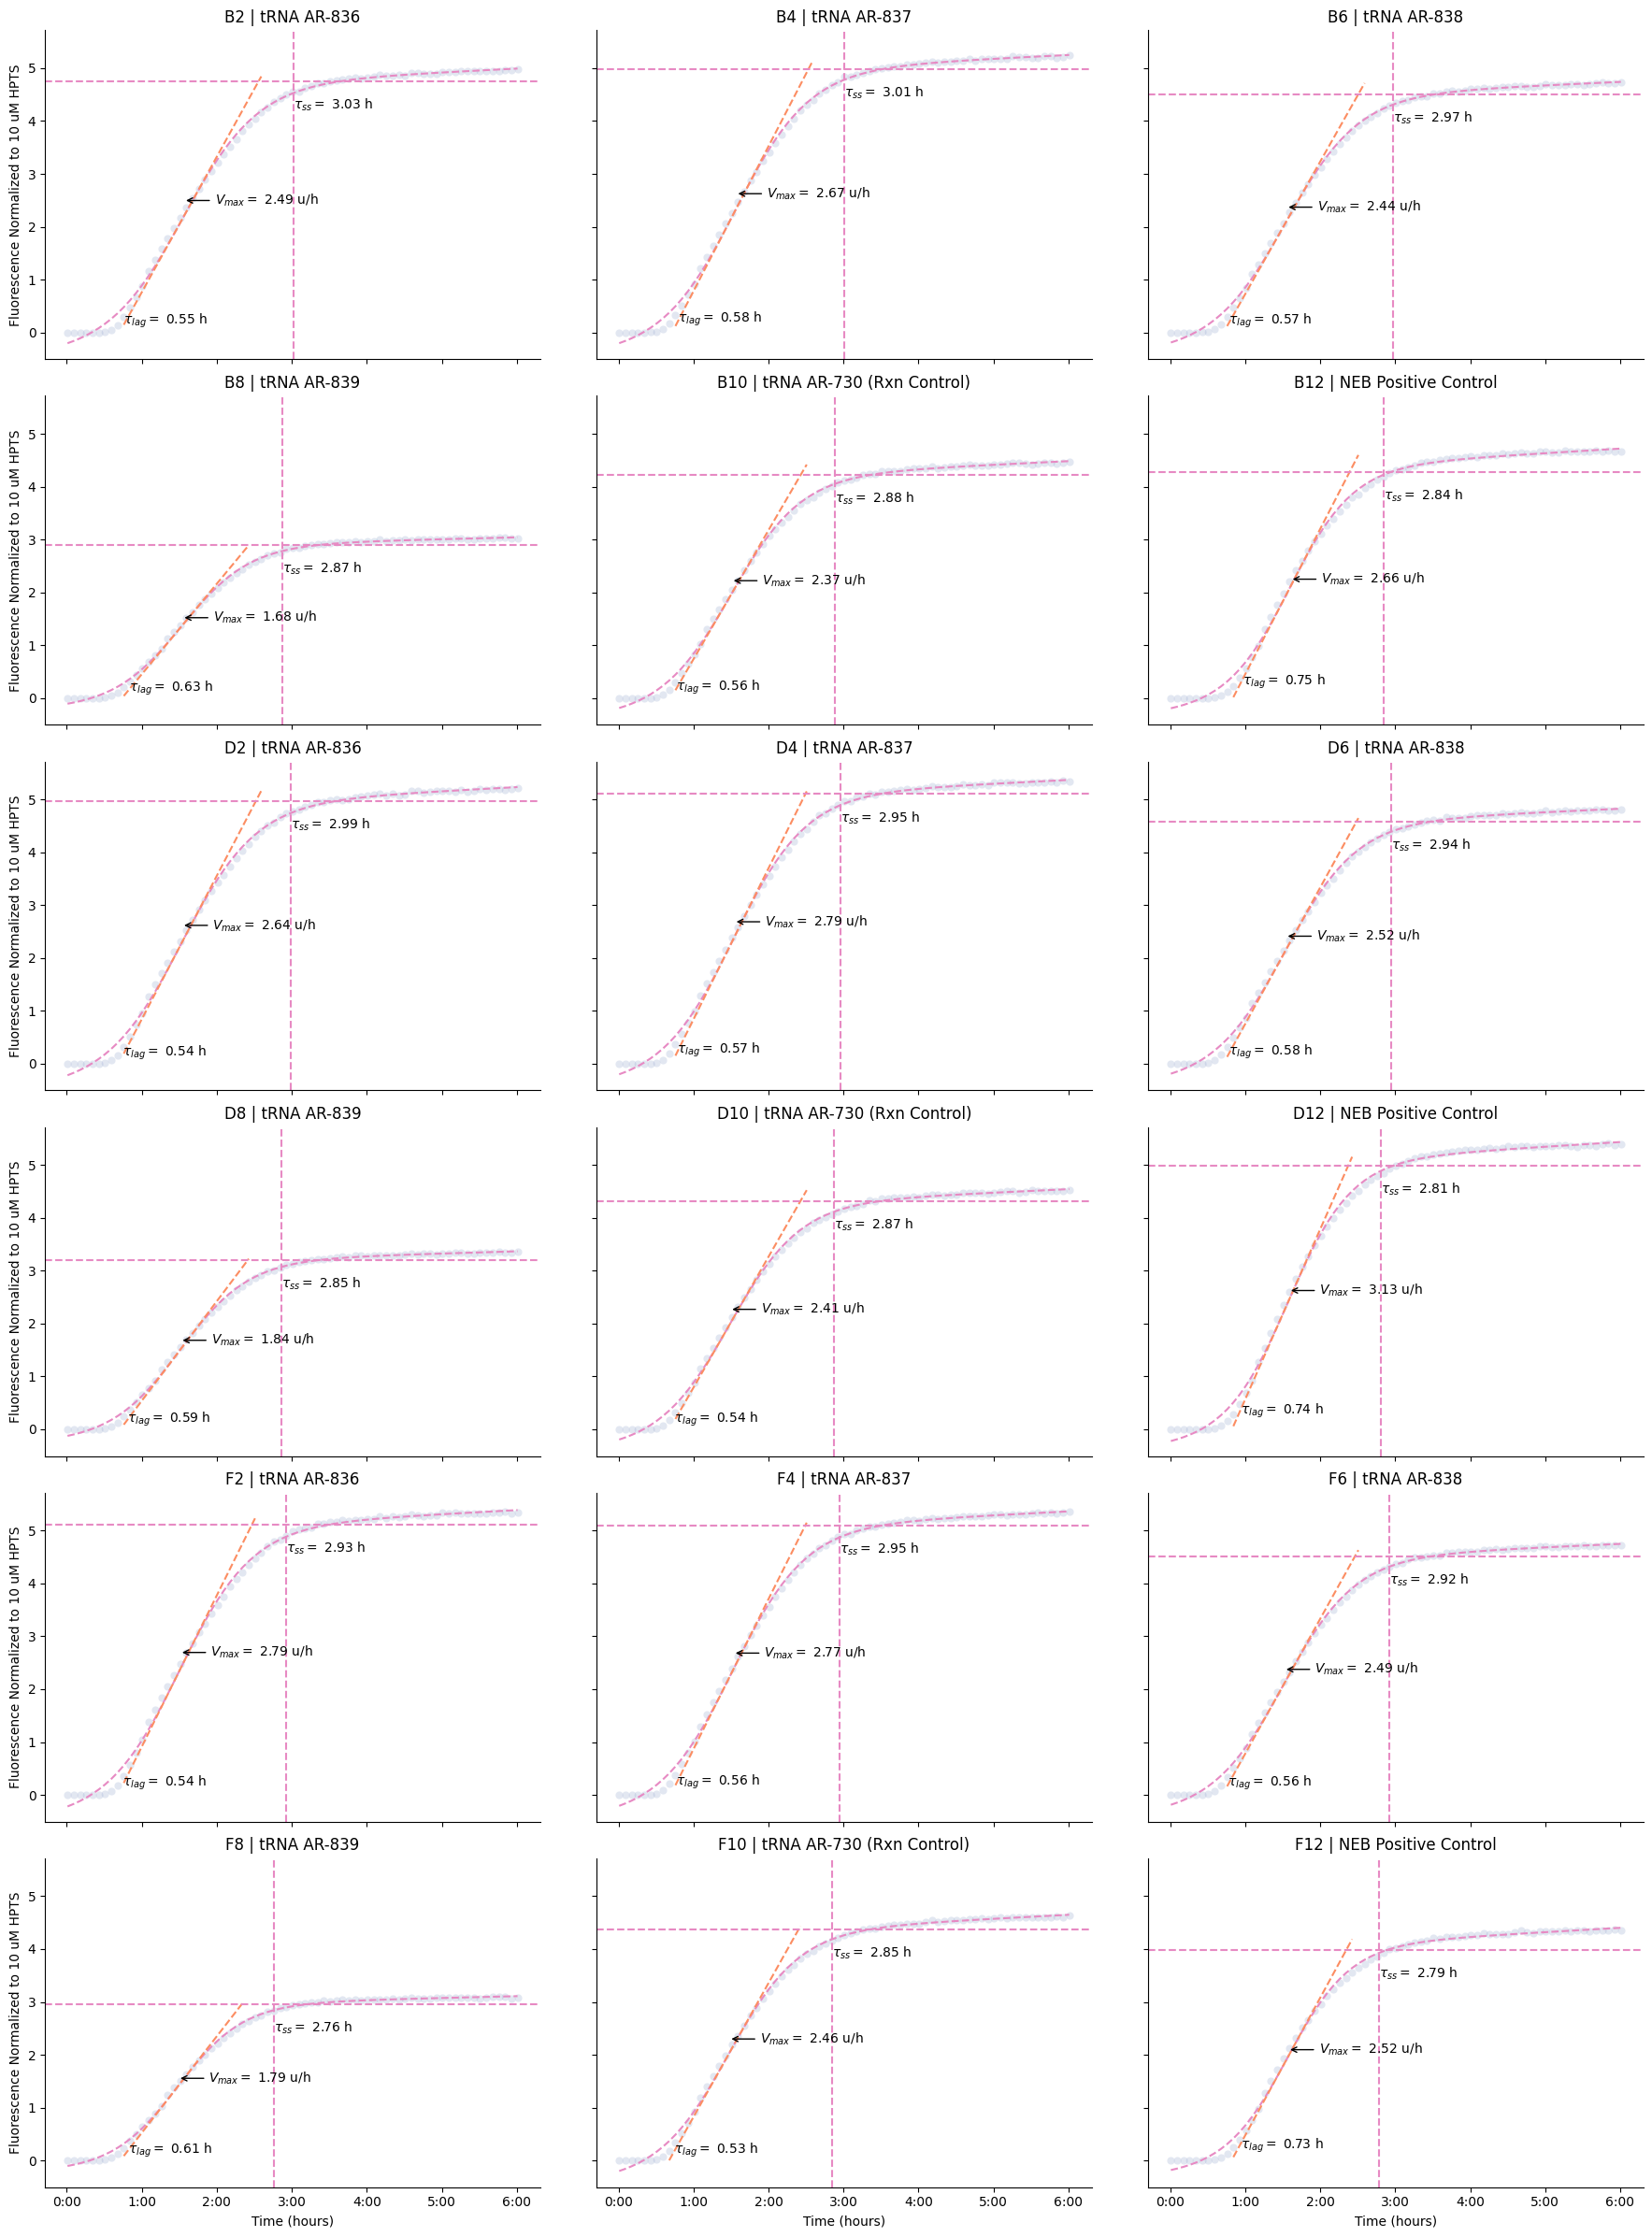

In [ ]:
g = kinetics.plot(col="Well")
# g = kinetics.plot() # call this to visualize across replicates

## Summary Plots

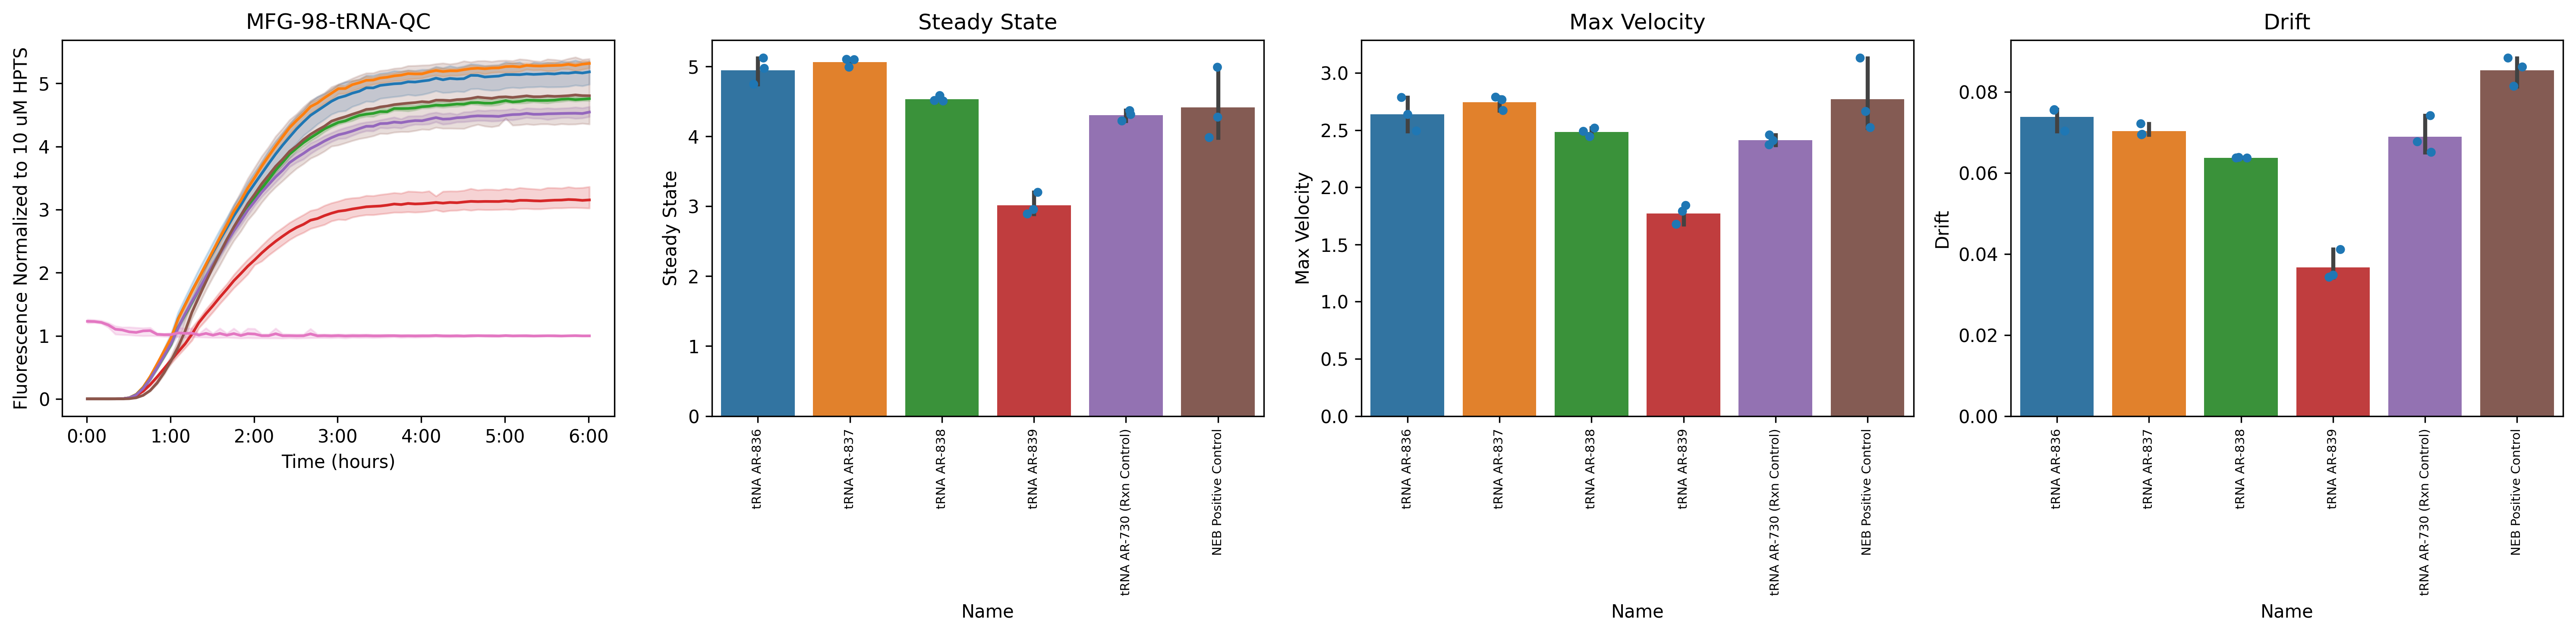

In [ ]:
g = kinetics.plot_summary()

## Key Metrics Explained

### 1. **Steady-State Level** (`Steady State, Data`)
- The final fluorescence value reached by the reaction
- Represents the total amount of protein produced
- Higher values indicate greater expression yield

### 2. **Maximum Velocity** (`Velocity, Max`)
- The steepest slope of the fluorescence curve (at the inflection point)
- Units: RFU per second
- Reflects the peak rate of protein synthesis
- Sensitive to enzyme activity, substrate availability, and reaction conditions

### 3. **Lag Time** (`Lag, Time`)
- Time before exponential fluorescence increase begins
- May reflect time for ribosome assembly or initial translation steps
- Shorter lag times suggest faster reaction initiation

### 4. **Drift** (`Fit, drift`)
- Rate of fluorescence change after reaching steady-state
- Positive drift: continued synthesis or aggregation
- Negative drift: photobleaching, protein degradation, or quenching
- Units: RFU per second

### 5. **R² Value** (`Fit, R^2`)
- Goodness of fit (0 to 1, higher is better)
- R² > 0.98 indicates excellent fit
- Poor fits may indicate noisy data, overflow errors, or non-sigmoid kinetics

## Tips and Troubleshooting

- **Overflow errors:** Wells with `OVRFLW` or `NaN` values are automatically excluded from fitting
- **Poor fits (low R²):** Inspect raw curves for anomalies (bubbles, evaporation, pipetting errors)
- **Drift:** Sometimes seen in kinetics curves; use `sigmoid_drift` model
- **Multiple replicates:** Always include technical replicates and report error bars
- **Comparing conditions:** Normalize or blank data consistently across all samples

## Next Steps

- Export kinetics results: `pr.export_kinetics(kinetics, 'results.csv')`
- Statistical analysis: Use `scipy.stats` or `statsmodels` for ANOVA/t-tests
- Parameter optimization: Vary Mg²⁺, K⁺, or other conditions to maximize Vmax or steady-state
- Mechanistic modeling: Fit ODE models to extract biological rate constants